In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###   **load dataset**

In [ ]:
customers=pd.read_csv("customer.csv")
orders=pd.read_csv("order.csv")
details=pd.read_csv("order_detail.csv")
products=pd.read_csv("products.csv")

In [ ]:
#merge the all file into one file dataframe
df=pd.DataFrame(
    customers.merge(orders,how='left',on='customer_id')
    .merge(details,how='left',on='order_id')
    .merge(products,how="left",on='product_id')
   )

In [ ]:
df.head()

,customer_id,name,segment,country,city,region,order_id,order_date,ship_date,ship_mode,months,product_id,sales,quantity,profit,discount,product_name,category,sub_category
0,DK-12835,Damala Kotsonis,Corporate,United States,Fremont,Central,CA-2017-168403,2017-09-09,2017-09-15,Standard Class,September,OFF-AP-10003278,11.2,1,0.8,0.2,Belkin 7_Outlet SurgeMaster Home Series,Office Supplies,Appliances
1,DK-12835,Damala Kotsonis,Corporate,United States,Fremont,Central,CA-2017-168403,2017-09-09,2017-09-15,Standard Class,September,OFF-PA-10002036,31.1,6,11.3,0.2,Xerox 1930,Office Supplies,Paper
2,DK-12835,Damala Kotsonis,Corporate,United States,Fremont,Central,CA-2017-149489,2017-04-24,2017-04-27,First Class,April,OFF-AP-10002495,99.3,2,12.4,0.2,Acco Smartsocket Table Surge Protector 6 Color...,Office Supplies,Appliances
3,DK-12835,Damala Kotsonis,Corporate,United States,Fremont,Central,CA-2017-149489,2017-04-24,2017-04-27,First Class,April,OFF-BI-10002414,7.5,2,-5.8,0.7,GBC ProClick Spines for 32_Hole Punch,Office Supplies,Binders
4,DK-12835,Damala Kotsonis,Corporate,United States,Fremont,Central,CA-2017-149489,2017-04-24,2017-04-27,First Class,April,OFF-BI-10002813,1.2,2,-1.0,0.7,Avery Reinforcements for Hole_Punch Pages,Office Supplies,Binders


## 2. Data Cleaning & Feature Engineering

In [ ]:
df.columns

Index(['customer_id', 'name', 'segment', 'country', 'city', 'region',
       'order_id', 'order_date', 'ship_date', 'ship_mode', 'months',
       'product_id', 'sales', 'quantity', 'profit', 'discount', 'product_name',
       'category', 'sub_category'],
      dtype='object')

In [ ]:
df.shape

(9993, 19)

In [ ]:
# convert date columns
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date']  = pd.to_datetime(df['ship_date'])
# check dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   customer_id   9993 non-null   object        
 1   name          9993 non-null   object        
 2   segment       9993 non-null   object        
 3   country       9993 non-null   object        
 4   city          9993 non-null   object        
 5   region        9993 non-null   object        
 6   order_id      9993 non-null   object        
 7   order_date    9993 non-null   datetime64[ns]
 8   ship_date     9993 non-null   datetime64[ns]
 9   ship_mode     9993 non-null   object        
 10  months        9993 non-null   object        
 11  product_id    9993 non-null   object        
 12  sales         9993 non-null   float64       
 13  quantity      9993 non-null   int64         
 14  profit        9993 non-null   float64       
 15  discount      9993 non-null   float64 

In [ ]:
# check duplicates
print('duplicate rows:', df.duplicated().sum())

duplicate rows: 0


In [ ]:
df.isna().sum()

customer_id     0
name            0
segment         0
country         0
city            0
region          0
order_id        0
order_date      0
ship_date       0
ship_mode       0
months          0
product_id      0
sales           0
quantity        0
profit          0
discount        0
product_name    0
category        0
sub_category    0
dtype: int64

In [ ]:
# statistical summary
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_date,9993,2016-04-30 01:53:33.089162496,2014-01-03 00:00:00,2015-05-23 00:00:00,2016-06-26 00:00:00,2017-05-14 00:00:00,2017-12-30 00:00:00,NaN
ship_date,9993,2016-05-04 00:53:19.039327744,2014-01-07 00:00:00,2015-05-27 00:00:00,2016-06-29 00:00:00,2017-05-18 00:00:00,2018-01-05 00:00:00,NaN
sales,9993.0,229.858561,0.4,17.3,54.5,209.9,22638.5,623.277095
quantity,9993.0,3.789753,1.0,2.0,3.0,5.0,14.0,2.225149
profit,9993.0,28.662174,-6600.0,1.7,8.7,29.4,8400.0,234.272715
discount,9993.0,0.156188,0.0,0.0,0.2,0.2,0.8,0.206457


In [ ]:
# --- feature engineering ---
df['shipping_delay'] = (df['ship_date'] - df['order_date']).dt.days

In [ ]:
df['loss'] = np.where(df['profit'] < 0, abs(df['profit']), 0)

In [ ]:
df['margin'] = (df['profit'] / df['sales'] * 100).round(2)

In [ ]:
# discount buckets
df['discount_bucket'] = pd.cut(
    df['discount'],
    bins=[-0.001, 0.0, 0.10, 0.20, 0.30, 1.0],
    labels=['no discount', '1-10%', '11-20%', '21-30%', '30%+']
)

In [ ]:
# month-year period for time series
df['month_year'] = df['order_date'].dt.to_period('M')
df['month_name'] = df['order_date'].dt.month_name()
df['year'] = df['order_date'].dt.year

df.head()

,customer_id,name,segment,country,city,region,order_id,order_date,ship_date,ship_mode,...,product_name,category,sub_category,shipping_delay,loss,margin,discount_bucket,month_year,month_name,year
0,DK-12835,Damala Kotsonis,Corporate,United States,Fremont,Central,CA-2017-168403,2017-09-09,2017-09-15,Standard Class,...,Belkin 7_Outlet SurgeMaster Home Series,Office Supplies,Appliances,6,0.0,7.14,11-20%,2017-09,September,2017
1,DK-12835,Damala Kotsonis,Corporate,United States,Fremont,Central,CA-2017-168403,2017-09-09,2017-09-15,Standard Class,...,Xerox 1930,Office Supplies,Paper,6,0.0,36.33,11-20%,2017-09,September,2017
2,DK-12835,Damala Kotsonis,Corporate,United States,Fremont,Central,CA-2017-149489,2017-04-24,2017-04-27,First Class,...,Acco Smartsocket Table Surge Protector 6 Color...,Office Supplies,Appliances,3,0.0,12.49,11-20%,2017-04,April,2017
3,DK-12835,Damala Kotsonis,Corporate,United States,Fremont,Central,CA-2017-149489,2017-04-24,2017-04-27,First Class,...,GBC ProClick Spines for 32_Hole Punch,Office Supplies,Binders,3,5.8,-77.33,30%+,2017-04,April,2017
4,DK-12835,Damala Kotsonis,Corporate,United States,Fremont,Central,CA-2017-149489,2017-04-24,2017-04-27,First Class,...,Avery Reinforcements for Hole_Punch Pages,Office Supplies,Binders,3,1.0,-83.33,30%+,2017-04,April,2017


## univariate analysis

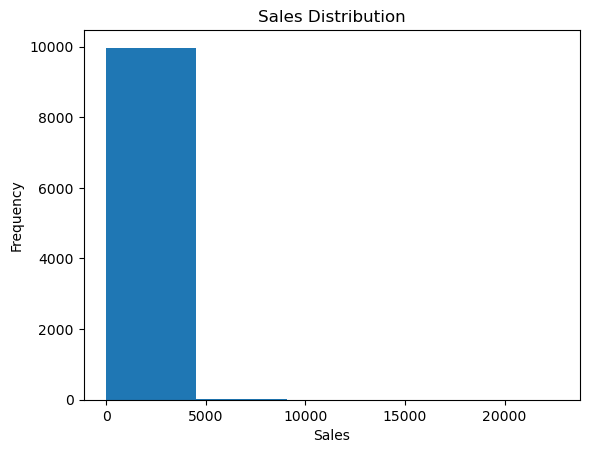

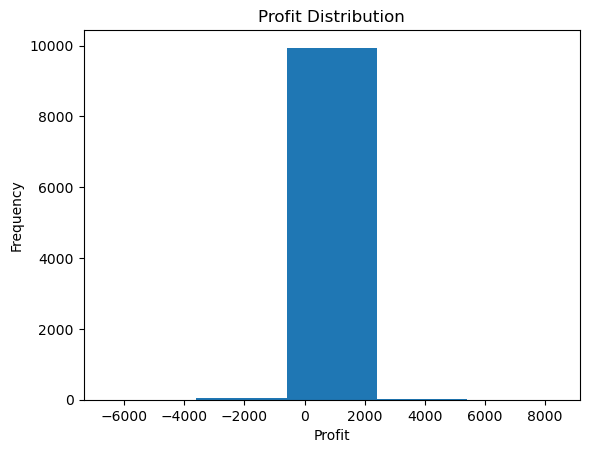

In [ ]:
# Sales Distribution
plt.hist(df['sales'], bins=5)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# Profit Distribution
plt.hist(df['profit'], bins=5)
plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# key business metrics summary
print('=== overall business metrics ===')
print(f"total sales:{df['sales'].sum():,.2f}")
print(f"total profit:{df['profit'].sum():,.2f}")
print(f"total loss:{df['loss'].sum():,.2f}")
print(f"avg margin:{df['margin'].mean():.2f}%")
print(f"total orders:{df['order_id'].nunique():,}")
print(f"total customers:{df['customer_id'].nunique():,}")

=== overall business metrics ===
total sales:2,296,976.60
total profit:286,421.10
total loss:156,120.30
avg margin:12.03%
total orders:5,009
total customers:793


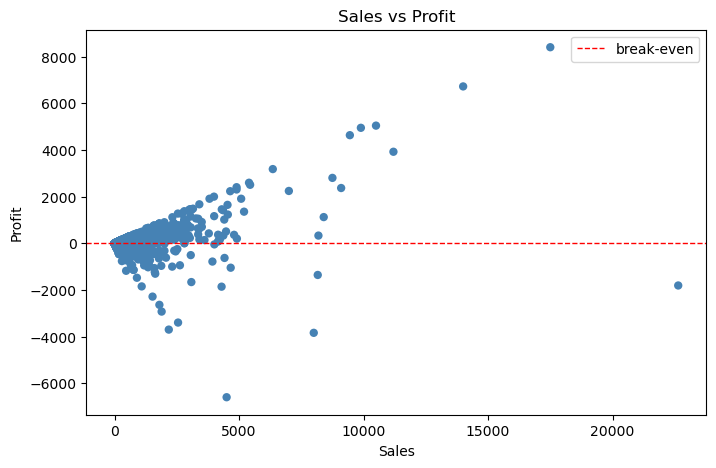

In [ ]:
# sales vs profit scatter
plt.figure(figsize=(8, 5))
plt.scatter(df['sales'], df['profit'], color='steelblue', edgecolors='none')
plt.axhline(0, color='red', linewidth=1, linestyle='--', label='break-even')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sales vs Profit')
plt.legend()
plt.show()

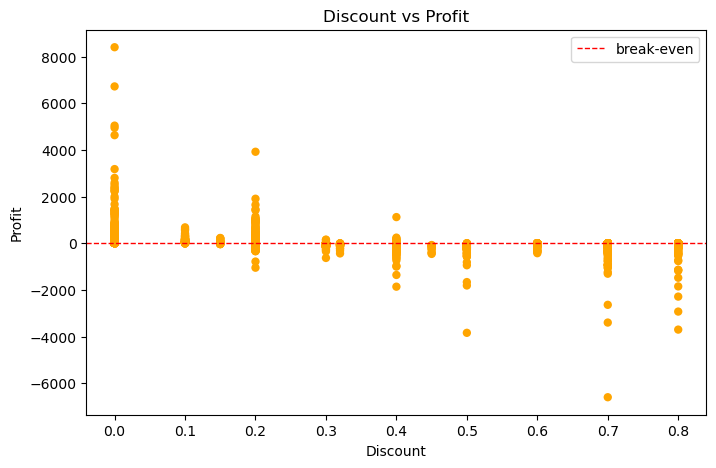

discount vs profit correlation: -0.219


In [ ]:
# discount vs profit scatter
plt.figure(figsize=(8, 5))
plt.scatter(df['discount'], df['profit'], color='orange', edgecolors='none')
plt.axhline(0, color='red', linewidth=1, linestyle='--', label='break-even')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.legend()
plt.show()

print('discount vs profit correlation:', round(df['discount'].corr(df['profit']), 3))

In [ ]:
bucket_summary = df.groupby('discount_bucket', observed=True)[['sales','profit','margin']].mean().round(3)
print(bucket_summary)

                   sales   profit  margin
discount_bucket                          
no discount      226.749   66.902  34.010
1-10%            578.396   96.053  15.576
11-20%           213.581   24.740  17.485
21-30%           455.515  -45.828 -11.580
30%+             222.599 -107.210 -91.477


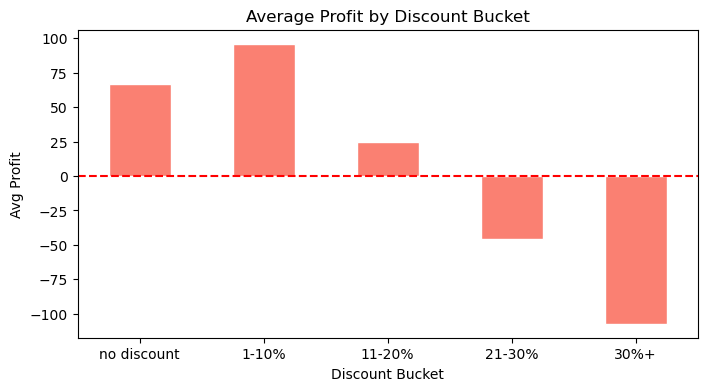

In [ ]:
bucket_summary['profit'].plot(kind='bar', color='salmon', edgecolor='white', figsize=(8,4))
plt.axhline(0, color='red', linestyle='--')
plt.title('Average Profit by Discount Bucket')
plt.xlabel('Discount Bucket')
plt.ylabel('Avg Profit')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Category-wise sales and profit summary
cat_perf = df.groupby('category')[['sales', 'profit']].sum().reset_index()
print(cat_perf)

          category     sales    profit
0        Furniture  741731.3   18465.8
1  Office Supplies  719067.0  122492.8
2       Technology  836178.3  145462.5


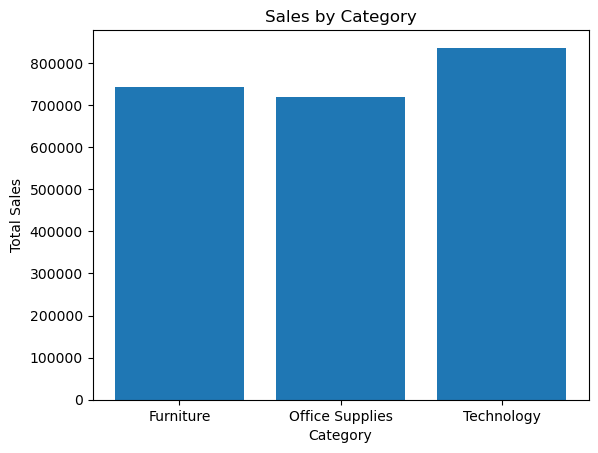

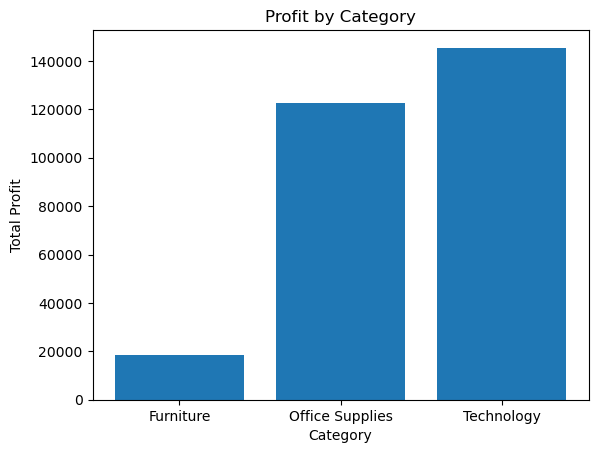

In [ ]:
# Sales by Category
plt.bar(cat_perf['category'], cat_perf['sales'])
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

# Profit by Category
plt.bar(cat_perf['category'], cat_perf['profit'])
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.show()

In [ ]:
# sub-category profitability
subcat_perf = (df.groupby('sub_category')[['sales','profit']].sum().sort_values('profit'))
subcat_perf

,sales,profit
sub_category,,
Tables,206967.4,-17725.4
Bookcases,114882.4,-3472.2
Supplies,46674.2,-1189.0
Fasteners,3024.8,949.9
Machines,189239.6,3384.9
Labels,12487.6,5545.8
Art,27120.8,6530.4
Envelopes,16478.0,6963.9
Furnishings,91709.9,13059.5


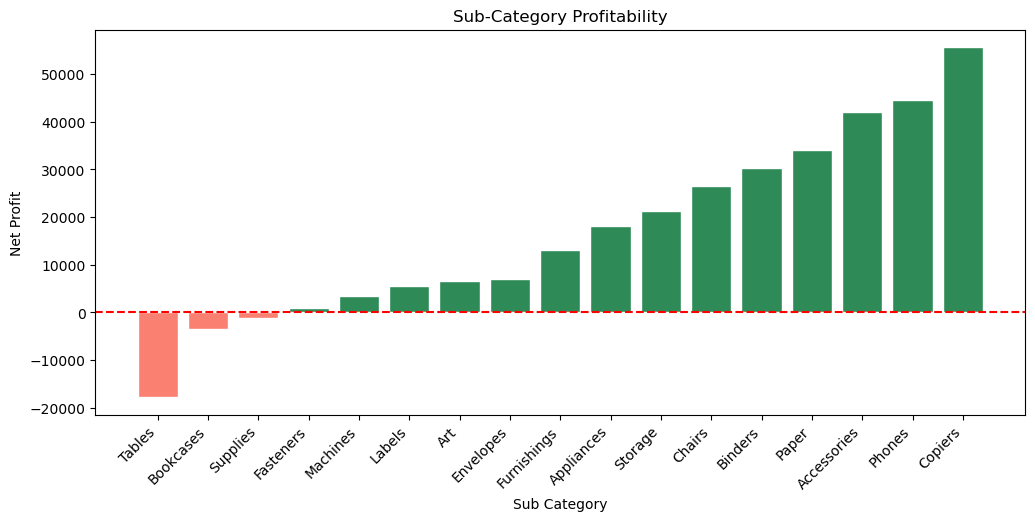

In [ ]:
colors = ['salmon' if v < 0 else 'seagreen' for v in subcat_perf['profit']]

plt.figure(figsize=(12, 5))
plt.bar(subcat_perf['sub_category'], subcat_perf['profit'], color=colors, edgecolor='white')
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title('Sub-Category Profitability')
plt.xlabel('Sub Category')
plt.ylabel('Net Profit')
plt.show()

In [ ]:
# top 10 loss-making products
product_loss = (df.groupby('product_name')[['profit','discount']].sum().reset_index().sort_values('profit').head(10))
print(product_loss)

                                           product_name  profit  discount
470           Cubify CubeX 3D Printer Double Head Print -8880.0      1.60
969           Lexmark MX611dhe Monochrome Laser Printer -4590.0      1.60
471           Cubify CubeX 3D Printer Triple Head Print -3840.0      0.50
421   Chromcraft Bull_Nose Wood Oval Conference Tabl... -2876.2      1.40
372   Bush Advantage Collection Racetrack Conference... -1934.3      2.45
672           GBC DocuBind P400 Electric Binding System -1878.2      2.70
440   Cisco TelePresence System EX90 Videoconferenci... -1811.1      0.50
1025  Martin Yale Chadless Opener Electric Letter Op... -1299.1      0.60
282                        Balt Solid Wood Round Tables -1201.0      0.80
360   BoxOffice By Design Rectangular and Half_Moon ... -1148.5      1.45


In [ ]:
# category wise discount impact
cat_discount = (df[df['discount'] > 0].groupby('category').agg(total_sales=('sales','sum'),
                                                               total_profit=('profit','sum'),
                                                               avg_discount=('discount','mean')).round(2).sort_values('total_profit'))
print(cat_discount)

                 total_sales  total_profit  avg_discount
category                                                
Furniture           485702.0      -39668.6          0.29
Office Supplies     276903.0       -8017.1          0.33
Technology          446432.1       13109.3          0.24


In [ ]:
# total profit lost due to high discounts
total_loss_discount = df[(df['discount'] > 0)]['loss'].sum()
print(f'total profit lost due to discounts:{total_loss_discount:,.2f}')

total profit lost due to discounts:156,120.30


In [ ]:
# customer wise sales, profit, loss
cust = (df.groupby('customer_id')[['sales','profit','loss']].sum().reset_index().sort_values('sales', ascending=False))

print('total customers:', len(cust))
cust.head(10)

total customers: 793


,customer_id,sales,profit,loss
700,SM-20320,25043.3,-1980.7,2077.0
741,TC-20980,19052.3,8981.5,44.3
621,RB-19360,15117.3,6976.0,8.6
730,TA-21385,14595.7,4703.9,75.8
6,AB-10105,14473.7,5445.0,402.4
434,KL-16645,14175.2,806.9,545.0
669,SC-20095,14142.3,5757.5,92.2
327,HL-15040,12873.2,5622.7,0.0
683,SE-20110,12209.7,2650.8,608.3
131,CC-12370,12129.2,2177.1,34.2


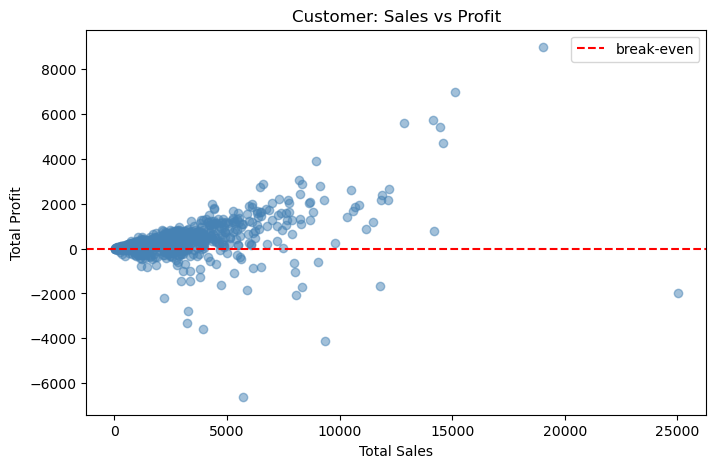

In [ ]:
# customer sales vs profit scatter
plt.figure(figsize=(8, 5))
plt.scatter(cust['sales'], cust['profit'], alpha=0.5, color='steelblue')
plt.axhline(0, color='red', linestyle='--', label='break-even')
plt.xlabel('Total Sales')
plt.ylabel('Total Profit')
plt.title('Customer: Sales vs Profit')
plt.legend()
plt.show()

In [ ]:
seg = (df.groupby('segment')[['sales','profit']].sum().reset_index())
seg['margin'] = (seg['profit'] / seg['sales'] * 100).round(2)
print(seg)

       segment      sales    profit  margin
0     Consumer  1161429.3  134124.8   11.55
1    Corporate   706165.6   91983.5   13.03
2  Home Office   429381.7   60312.8   14.05


    region     sales   profit
0  Central  577730.2  76222.2
1     East  545410.8  59483.8
2    South  482989.7  59323.1
3     West  690845.9  91392.0


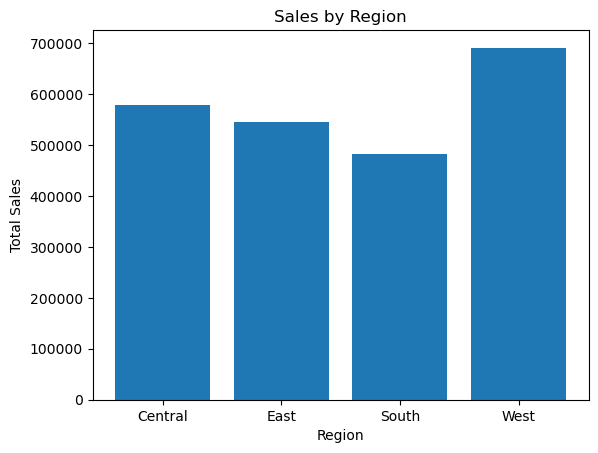

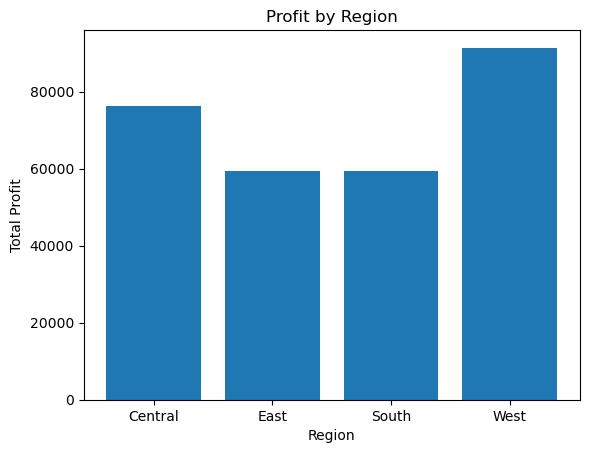

In [ ]:
# Region-wise sales and profit summary
region = df.groupby('region')[['sales', 'profit']].sum().reset_index()
print(region)

# Sales by Region
plt.bar(region['region'], region['sales'])
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

# Profit by Region
plt.bar(region['region'], region['profit'])
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

In [ ]:
# average shipping delay per ship mode
ship = (df.groupby('ship_mode')['shipping_delay'].agg(['mean','min','max']).round(2)
        .rename(columns={'mean':'avg_days','min':'min_days','max':'max_days'}).reset_index())
print(ship)

        ship_mode  avg_days  min_days  max_days
0     First Class      2.18         1         4
1        Same Day      0.04         0         1
2    Second Class      3.24         1         5
3  Standard Class      5.01         3         7


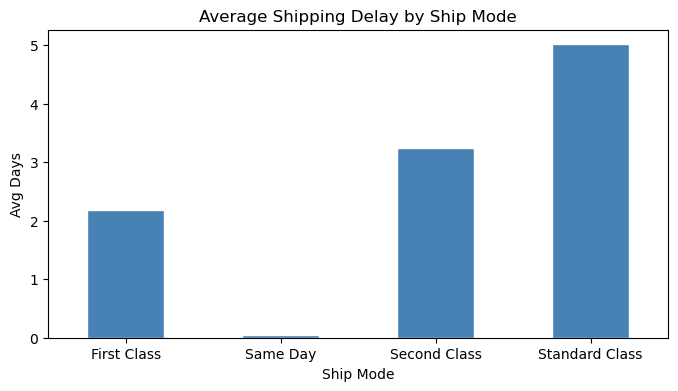

In [ ]:
ship.plot(x='ship_mode', y='avg_days', kind='bar',color='steelblue', edgecolor='white', figsize=(8,4), legend=False)
plt.title('Average Shipping Delay by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Avg Days')
plt.xticks(rotation=0)
plt.show()

In [ ]:
df['month_year'] = df['order_date'].dt.to_period('M')
monthly = df.groupby('month_year')[['sales','profit','loss']].sum()

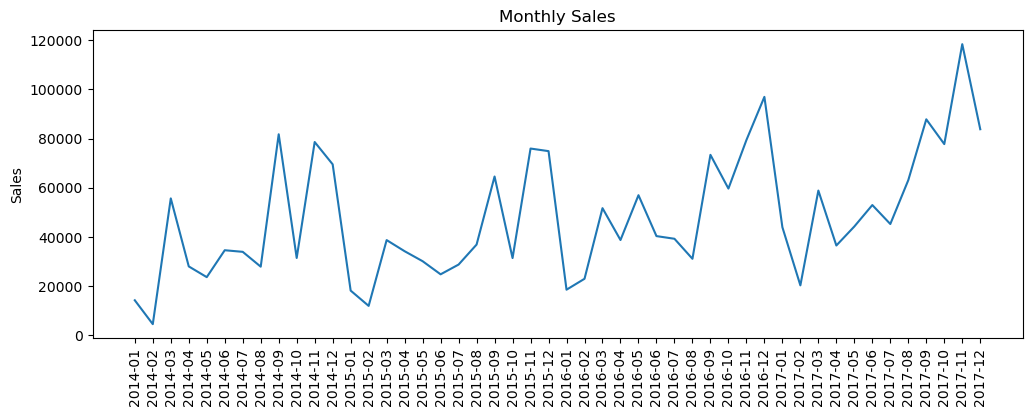

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(monthly.index.astype(str), monthly['sales'])
plt.title('Monthly Sales')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.show()

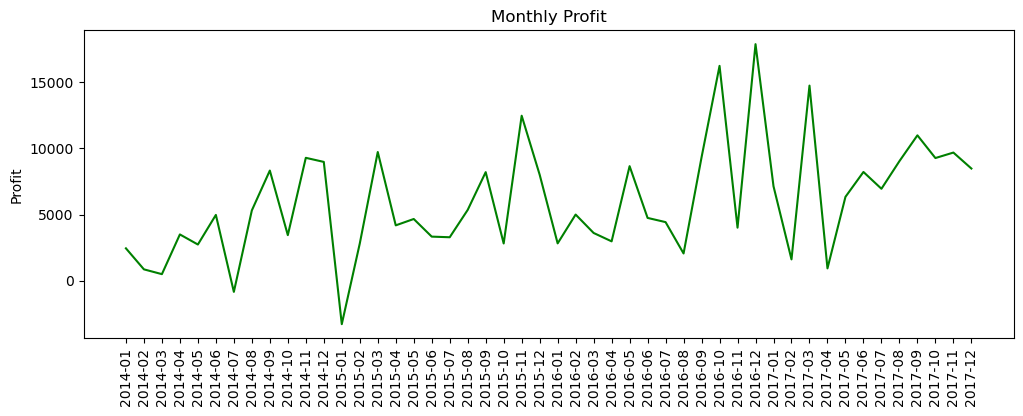

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(monthly.index.astype(str), monthly['profit'],color='green')
plt.title('Monthly Profit')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.show()

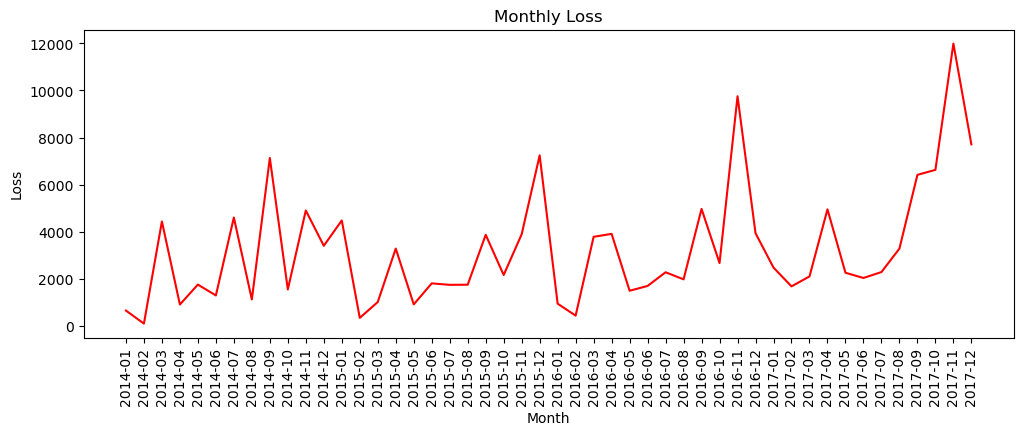

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(monthly.index.astype(str), monthly['loss'],color='red')
plt.title('Monthly Loss')
plt.ylabel('Loss')
plt.xlabel('Month')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df['month_name'] = df['order_date'].dt.month_name()
df.groupby('month_name')['profit'].mean()

month_name
April        17.391604
August       30.846317
December     30.802344
February     34.312000
January      23.977690
July         19.482535
June         29.688006
March        41.085489
May          30.492381
November     24.113460
October      38.809280
September    26.654085
Name: profit, dtype: float64

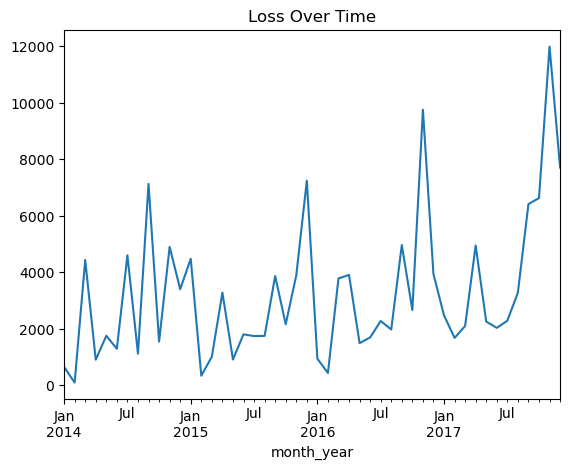

In [ ]:
monthly['loss'].plot()
plt.title("Loss Over Time")
plt.show()

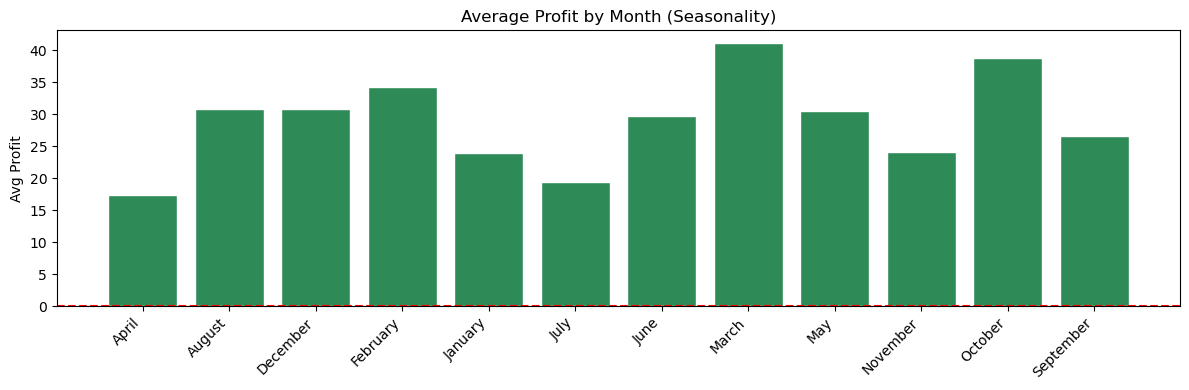

In [ ]:
# average profit by month name (seasonality)
monthly_avg = (df.groupby('month_name')['profit'].mean().reset_index())

plt.figure(figsize=(12, 4))
colors = ['seagreen' if v >= 0 else 'salmon' for v in monthly_avg['profit']]
plt.bar(monthly_avg['month_name'], monthly_avg['profit'], color=colors, edgecolor='white')
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title('Average Profit by Month (Seasonality)')
plt.ylabel('Avg Profit')
plt.tight_layout()
plt.show()

In [ ]:
df[['sales','profit','loss']].corr()

,sales,profit,loss
sales,1.000000,0.479067,0.265286
profit,0.479067,1.000000,-0.566496
loss,0.265286,-0.566496,1.000000


In [ ]:
numeric_df = df[['sales', 'quantity', 'profit', 'discount', 'shipping_delay', 'margin']]
corr = numeric_df.corr()
corr

,sales,quantity,profit,discount,shipping_delay,margin
sales,1.000000,0.200804,0.479067,-0.028197,-0.007353,0.003471
quantity,0.200804,1.000000,0.066244,0.008680,0.018301,-0.005243
profit,0.479067,0.066244,1.000000,-0.219483,-0.004648,0.223720
discount,-0.028197,0.008680,-0.219483,1.000000,0.000407,-0.864389
shipping_delay,-0.007353,0.018301,-0.004648,0.000407,1.000000,-0.011849
margin,0.003471,-0.005243,0.223720,-0.864389,-0.011849,1.000000


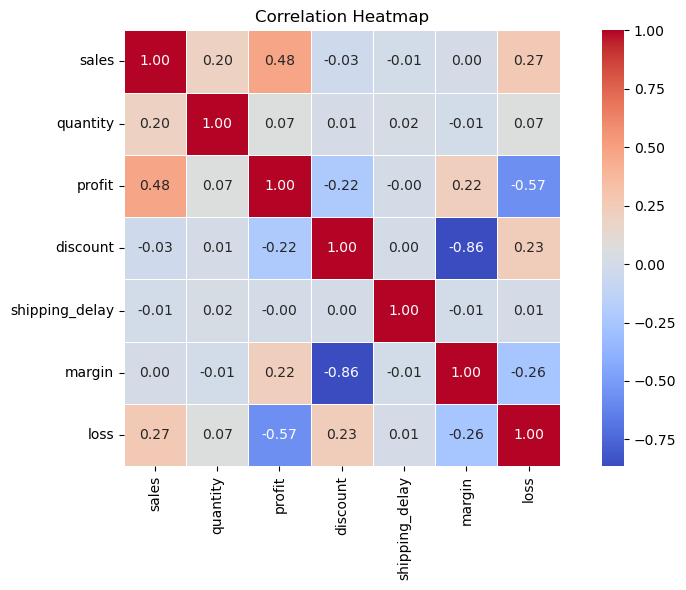

In [ ]:
numeric_df = df[['sales','quantity','profit','discount','shipping_delay','margin','loss']]
corr = numeric_df.corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()